# Libraries

In [1]:
!pip install scikit-learn==1.8.0 xgboost==3.2.0 imbalanced-learn==0.14.1 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 35.0 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder, OneHotEncoder

from sklearn.model_selection import train_test_split, RandomizedSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline

from sklearn.model_selection import cross_validate, StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)

from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

import shap

# Load Dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# EDA - Data Understanding

In [4]:
filepath = '/content/drive/MyDrive/DSA_ICT/Data/Emp_attrition_csv.csv'
df=pd.read_csv(filepath)

print(df.shape)
df.head()

(74610, 24)


,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure (In Months),Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89.0,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21.0,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74.0,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50.0,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68.0,No,No,No,Fair,Medium,Stayed


In [5]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74610 entries, 0 to 74609
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee ID                 74610 non-null  int64  
 1   Age                         74610 non-null  int64  
 2   Gender                      74610 non-null  object 
 3   Years at Company            74610 non-null  int64  
 4   Job Role                    74610 non-null  object 
 5   Monthly Income              74610 non-null  int64  
 6   Work-Life Balance           74610 non-null  object 
 7   Job Satisfaction            74610 non-null  object 
 8   Performance Rating          74610 non-null  object 
 9   Number of Promotions        74610 non-null  int64  
 10  Overtime                    74610 non-null  object 
 11  Distance from Home          72698 non-null  float64
 12  Education Level             74610 non-null  object 
 13  Marital Status              746

# Drop Irrelevant Column & Convert Target

Attrition
0    39191
1    35419
Name: count, dtype: int64
Attrition
0    0.525278
1    0.474722
Name: proportion, dtype: float64


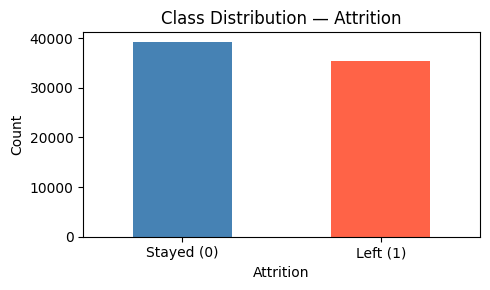

In [6]:
# Drop Employee ID — not useful for prediction
df.drop(columns=['Employee ID'], inplace=True)

# Convert target to binary
df['Attrition'] = df['Attrition'].map({'Stayed': 0, 'Left': 1})

# Class imbalance check
print(df['Attrition'].value_counts())
print(df['Attrition'].value_counts(normalize=True))

# Visualise
plt.figure(figsize=(5, 3))
df['Attrition'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.xticks([0, 1], ['Stayed (0)', 'Left (1)'], rotation=0)
plt.title('Class Distribution — Attrition')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


# Null & Duplicate Check

In [7]:
print("Null values per column:")
print(df.isnull().sum())

print("Duplicate rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Shape after dropping duplicates:", df.shape)

Null values per column:
Age                              0
Gender                           0
Years at Company                 0
Job Role                         0
Monthly Income                   0
Work-Life Balance                0
Job Satisfaction                 0
Performance Rating               0
Number of Promotions             0
Overtime                         0
Distance from Home            1912
Education Level                  0
Marital Status                   0
Number of Dependents             0
Job Level                        0
Company Size                     0
Company Tenure (In Months)    2413
Remote Work                      0
Leadership Opportunities         0
Innovation Opportunities         0
Company Reputation               0
Employee Recognition             0
Attrition                        0
dtype: int64
Duplicate rows: 112
Shape after dropping duplicates: (74498, 23)


# Distribution & Skewness Check

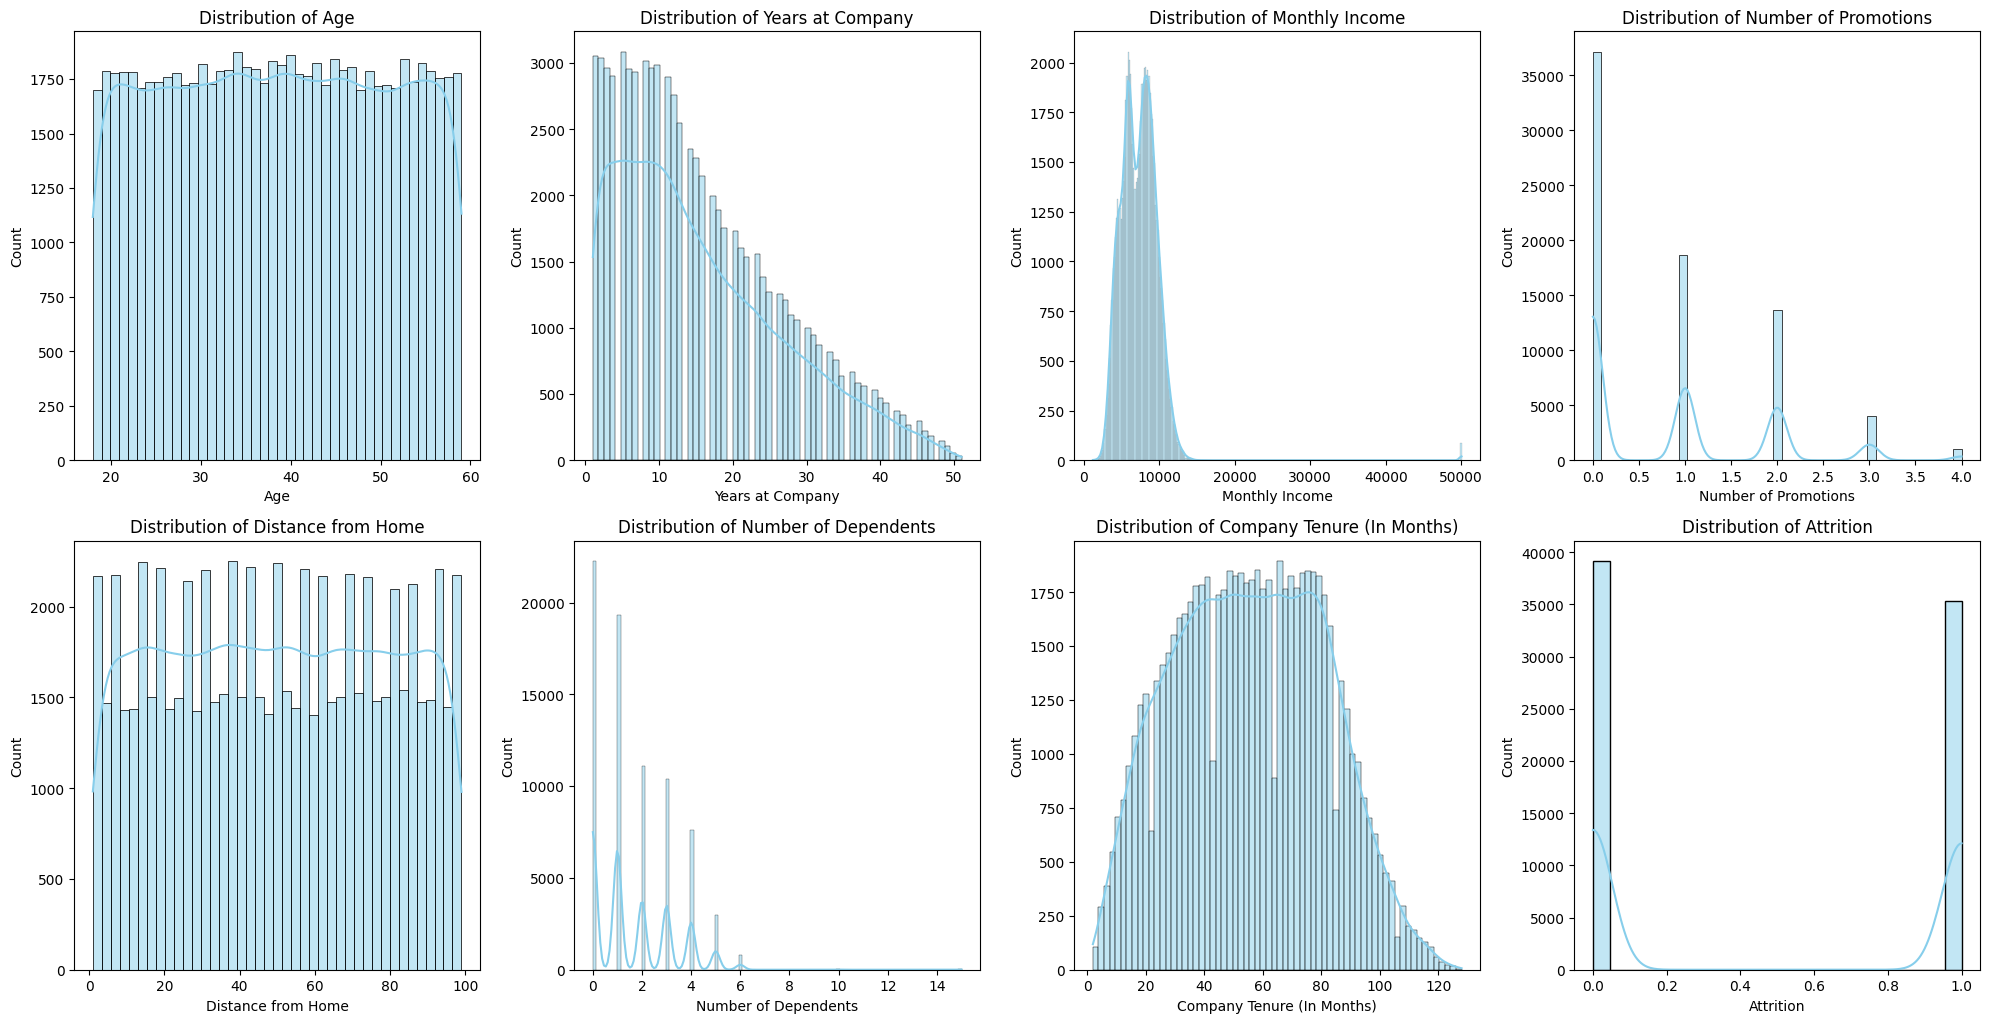

Skewness Table:
Age                          -0.001608
Years at Company              0.789908
Monthly Income                5.207805
Number of Promotions          0.992795
Distance from Home            0.001634
Number of Dependents          0.918378
Company Tenure (In Months)    0.066230
Attrition                     0.101019
dtype: float64


In [8]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Plotting distributions/outlier
plt.figure(figsize=(20, 15))
for i, col in enumerate(num_cols):
    plt.subplot(3, 4, i + 1)
    sns.histplot(df[col].dropna(), kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Print Skewness
print("Skewness Table:")
print(df[num_cols].skew())

# Log Transform Skewed Column

In [9]:
# Log transform highly skewed column
df['Monthly Income'] = np.log1p(df['Monthly Income'])
print("Monthly Income skewness after log transform:", round(df['Monthly Income'].skew(), 4))

Monthly Income skewness after log transform: -0.2618


# Fix String Issues in Education Level

In [10]:
df['Education Level'] = df['Education Level'].str.replace('Bachelorâ€™s Degree', 'Bachelors Degree', regex=False)
df['Education Level'] = df['Education Level'].str.replace('Masterâ€™s Degree', 'Masters Degree', regex=False)

print("Education Level unique values:")
print(df['Education Level'].unique())

Education Level unique values:
['Associate Degree' 'Masters Degree' 'Bachelors Degree' 'High School'
 'PhD']


# Feature Engineering

In [11]:
# Promotion rate: how fast is employee being promoted
df['Promotion_Rate'] = df['Number of Promotions'] / (df['Years at Company'])
df.loc[df['Years at Company'] == 0, 'Promotion_Rate'] = 0

# High performer with no promotion — attrition risk signal
df['HighPerf_NoPromo'] = ((df['Performance Rating'] == 'High') & (df['Number of Promotions'] == 0)).astype(int)

# Relative income vs role peers
df['Income_vs_Role_Avg'] = (df['Monthly Income'] / df.groupby('Job Role')['Monthly Income'].transform('mean')
)

print("New features added:")
print(df[['Promotion_Rate', 'HighPerf_NoPromo', 'Income_vs_Role_Avg']].describe())

New features added:
       Promotion_Rate  HighPerf_NoPromo  Income_vs_Role_Avg
count    74498.000000      74498.000000        74498.000000
mean         0.123879          0.099949            1.000000
std          0.302307          0.299934            0.020267
min          0.000000          0.000000            0.788367
25%          0.000000          0.000000            0.989582
50%          0.021277          0.000000            1.001164
75%          0.117647          0.000000            1.011840
max          4.000000          1.000000            1.204944


# Correlation Analysis

Attrition                     1.000000
Job Level                    -0.315289
Marital Status                0.228803
Remote Work                  -0.221191
Gender                       -0.100637
Distance from Home            0.094018
Number of Promotions         -0.081184
Number of Dependents         -0.074495
Years at Company             -0.065388
Work-Life Balance             0.063416
Overtime                      0.056019
Education Level              -0.051912
Age                          -0.050801
Job Satisfaction              0.050305
Company Reputation            0.036295
Performance Rating            0.032360
Company Tenure (In Months)   -0.029041
Company Size                  0.024118
Innovation Opportunities     -0.021548
Monthly Income               -0.012487
Leadership Opportunities     -0.011995
Job Role                     -0.010433
Promotion_Rate               -0.008468
Income_vs_Role_Avg           -0.006377
HighPerf_NoPromo              0.001506
Employee Recognition     

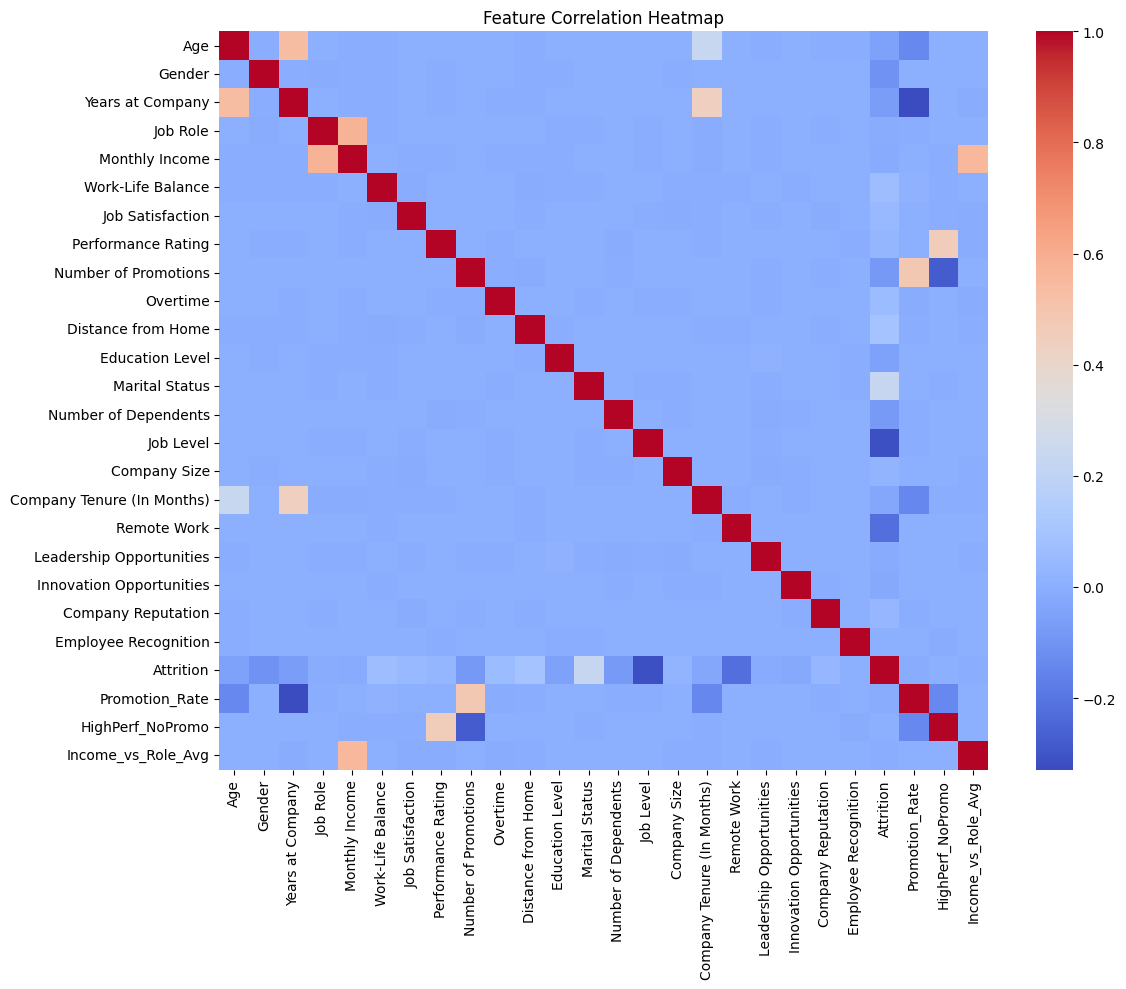

In [12]:
df_corr = df.copy()
cat_cols_temp = df_corr.select_dtypes(include='object').columns
for col in cat_cols_temp:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col].astype(str))

corr = df_corr.corr(numeric_only=True)['Attrition']
print(corr.sort_values(key=abs, ascending=False))

plt.figure(figsize=(12, 10))
sns.heatmap(df_corr.corr(numeric_only=True), cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# clean up, don't pollute df
del df_corr

# Define Feature Groups for the Pipeline

In [13]:
# Check categorical and numerical columns
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(include=['float', 'int']).columns

print("Categorical columns:", cat_cols.tolist())
print("Numerical columns:", num_cols.tolist())

Categorical columns: ['Gender', 'Job Role', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Overtime', 'Education Level', 'Marital Status', 'Job Level', 'Company Size', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition']
Numerical columns: ['Age', 'Years at Company', 'Monthly Income', 'Number of Promotions', 'Distance from Home', 'Number of Dependents', 'Company Tenure (In Months)', 'Attrition', 'Promotion_Rate', 'HighPerf_NoPromo', 'Income_vs_Role_Avg']


In [14]:
for col in cat_cols:
    print(col, df[col].unique())


Gender ['Male' 'Female']
Job Role ['Education' 'Media' 'Healthcare' 'Technology' 'Finance']
Work-Life Balance ['Excellent' 'Poor' 'Good' 'Fair']
Job Satisfaction ['Medium' 'High' 'Very High' 'Low']
Performance Rating ['Average' 'Low' 'High' 'Below Average']
Overtime ['No' 'Yes']
Education Level ['Associate Degree' 'Masters Degree' 'Bachelors Degree' 'High School'
 'PhD']
Marital Status ['Married' 'Divorced' 'Single']
Job Level ['Mid' 'Senior' 'Entry']
Company Size ['Medium' 'Small' 'Large']
Remote Work ['No' 'Yes']
Leadership Opportunities ['No' 'Yes']
Innovation Opportunities ['No' 'Yes']
Company Reputation ['Excellent' 'Fair' 'Poor' 'Good']
Employee Recognition ['Medium' 'Low' 'High' 'Very High']


In [15]:
# These are column lists that the ColumnTransformer will use.
# Imputation, scaling, encoding will ALL happen inside the pipeline.

# Numerical columns — will be imputed (if missing) then scaled
numerical_cols = [
    'Age',
    'Distance from Home',
    'Years at Company',
    'Number of Promotions',
    'Number of Dependents',
    'Company Tenure (In Months)',
    'Monthly Income',        # already log-transformed
    'Promotion_Rate',
    'Income_vs_Role_Avg'
]

# Ordinal columns — meaningful order matters
ordinal_features = {
    'Work-Life Balance':    ['Poor', 'Fair', 'Good', 'Excellent'],
    'Performance Rating':   ['Low', 'Below Average', 'Average', 'High'],
    'Job Level':            ['Entry', 'Mid', 'Senior'],
    'Company Reputation':   ['Poor', 'Fair', 'Good', 'Excellent'],
    'Education Level':      ['High School', 'Associate Degree', 'Bachelors Degree', 'Masters Degree', 'PhD'],
    'Job Satisfaction':     ['Low', 'Medium', 'High', 'Very High'],
    'Employee Recognition': ['Low', 'Medium', 'High', 'Very High'],
}

# Extract cols and orders from the dict
ordinal_cols   = list(ordinal_features.keys())
ordinal_orders = list(ordinal_features.values())

# HighPerf_NoPromo is already 0/1 from feature engineering
binary_cols = [
    'Gender',
    'Overtime',
    'Remote Work',
    'Leadership Opportunities',
    'Innovation Opportunities',
    'HighPerf_NoPromo'
]

# One-hot columns — nominal, no order
ohe_cols = ['Job Role', 'Marital Status', 'Company Size']

print("Column groups defined:")
print(f"  numerical  : {len(numerical_cols)} cols")
print(f"  ordinal    : {len(ordinal_cols)} cols")
print(f"  binary     : {len(binary_cols)} cols")
print(f"  one-hot    : {len(ohe_cols)} cols")

Column groups defined:
  numerical  : 9 cols
  ordinal    : 7 cols
  binary     : 6 cols
  one-hot    : 3 cols


# Split Features and Target

In [16]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

print("X shape:", X.shape)
print("y value counts:\n", y.value_counts())

X shape: (74498, 25)
y value counts:
 Attrition
0    39128
1    35370
Name: count, dtype: int64


# Train - Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest class distribution:")
print(y_test.value_counts(normalize=True).round(3))

Train: (59598, 25) | Test: (14900, 25)

Train class distribution:
Attrition
0    0.525
1    0.475
Name: proportion, dtype: float64

Test class distribution:
Attrition
0    0.525
1    0.475
Name: proportion, dtype: float64


# Build the Preprocessing Pipeline (ColumnTransformer)

In [18]:
# Numerical sub-pipeline: impute missing → scale
numerical_pipeline = Pipeline([
    ('imputer', IterativeImputer(max_iter=10, random_state=42)),
    ('scaler',  StandardScaler())
])

# Ordinal sub-pipeline: impute missing (most frequent) → ordinal encode
ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=ordinal_orders,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

# Binary sub-pipeline: impute → ordinal encode as 0/1
# OrdinalEncoder on 2-class columns gives same result as LabelEncoder
binary_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# One-hot sub-pipeline: impute → one-hot encode
ohe_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop=None, sparse_output=False, handle_unknown='ignore'))
])

# ColumnTransformer — combines all sub-pipelines
preprocessor = ColumnTransformer(transformers=[
    ('numerical', numerical_pipeline, numerical_cols),
    ('ordinal',   ordinal_pipeline,   ordinal_cols),
    ('binary',    binary_pipeline,    binary_cols),
    ('ohe',       ohe_pipeline,       ohe_cols),
], remainder='drop')


# Model Selection

In [19]:
models = {

    "Logistic Regression": Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]),

    "Linear SVC": Pipeline([
        ('preprocessor', preprocessor),
        ('model', CalibratedClassifierCV(
            LinearSVC(max_iter=2000, random_state=42),
            cv=3
        ))
    ]),

    "Naive Bayes": Pipeline([
        ('preprocessor', preprocessor),
        ('model', GaussianNB())
    ]),

    "Random Forest": Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=200,
            n_jobs=-1,
            random_state=42
        ))
    ]),

    "XGBoost": Pipeline([
        ('preprocessor', preprocessor),
        ('model', XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            random_state=42,
            eval_metric='logloss',
            n_jobs=-1
        ))
    ]),
}

print("Model pipelines defined:")
for name, pipe in models.items():
    print(f"  {name}: {[s[0] for s in pipe.steps]}")

Model pipelines defined:
  Logistic Regression: ['preprocessor', 'model']
  Linear SVC: ['preprocessor', 'model']
  Naive Bayes: ['preprocessor', 'model']
  Random Forest: ['preprocessor', 'model']
  XGBoost: ['preprocessor', 'model']


# Feature Importance Preview (Quick Sanity Check)
Fit on X_train only (no leakage)

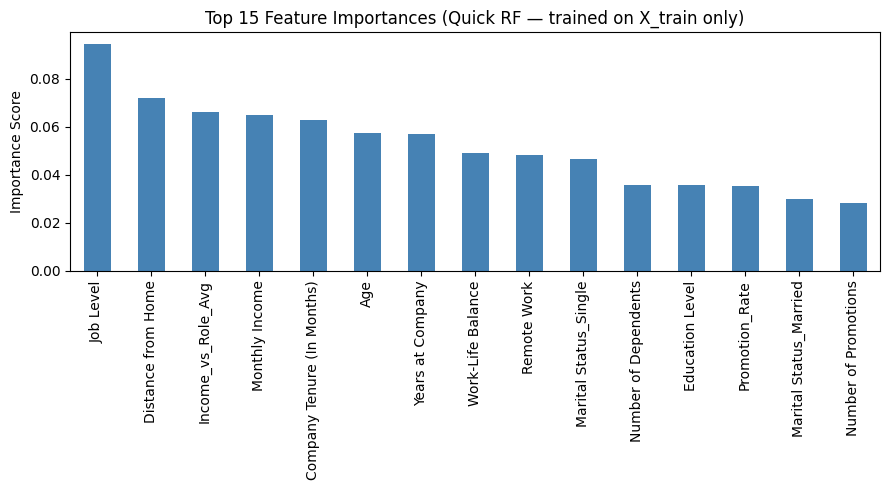


Top 10 features:
 Job Level                     0.094730
Distance from Home            0.072105
Income_vs_Role_Avg            0.066185
Monthly Income                0.064750
Company Tenure (In Months)    0.062992
Age                           0.057536
Years at Company              0.057023
Work-Life Balance             0.049090
Remote Work                   0.048162
Marital Status_Single         0.046478
dtype: float64


In [20]:
rf_quick_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

rf_quick_pipeline.fit(X_train, y_train)

# Get feature names after ColumnTransformer
ohe_feature_names = (
    rf_quick_pipeline.named_steps['preprocessor']
    .named_transformers_['ohe']
    .named_steps['encoder']
    .get_feature_names_out(ohe_cols)
    .tolist()
)

all_feature_names = numerical_cols + ordinal_cols + binary_cols + ohe_feature_names

importance = pd.Series(
    rf_quick_pipeline.named_steps['model'].feature_importances_,
    index=all_feature_names
)
importance = importance.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 5))
importance.plot(kind='bar', color='steelblue')
plt.title('Top 15 Feature Importances (Quick RF — trained on X_train only)')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 10 features:\n", importance.head(10))

# Cross-Validation Training

In [21]:
scoring = {
    'accuracy':  'accuracy',
    'precision': make_scorer(precision_score, pos_label=1, zero_division=0),
    'recall':    make_scorer(recall_score, pos_label=1),
    'f1':        make_scorer(f1_score, pos_label=1),
    'roc_auc':   'roc_auc'
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")

    cv_results = cross_validate(
        model, X_train, y_train,    # ← X_train raw, pipeline preprocesses each fold
        cv=skf,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    mean_accuracy  = cv_results['test_accuracy'].mean()
    mean_precision = cv_results['test_precision'].mean()
    mean_recall    = cv_results['test_recall'].mean()
    mean_f1        = cv_results['test_f1'].mean()
    mean_roc       = cv_results['test_roc_auc'].mean()
    train_roc      = cv_results['train_roc_auc'].mean()

    print(f"  Train ROC-AUC : {train_roc:.4f}")
    print(f"  Test  ROC-AUC : {mean_roc:.4f}")
    print(f"  Accuracy      : {mean_accuracy:.4f}")
    print(f"  Precision     : {mean_precision:.4f}")
    print(f"  Recall        : {mean_recall:.4f}")
    print(f"  F1 Score      : {mean_f1:.4f}")

    gap = train_roc - mean_roc
    if gap > 0.1:
        print(f"Possible overfitting (train-test gap = {gap:.3f})")
    else:
        print(f"No overfitting (train-test gap = {gap:.3f})")

    results.append({
        'Model':     name,
        'ROC-AUC':   round(mean_roc, 4),
        'F1':        round(mean_f1, 4),
        'Recall':    round(mean_recall, 4),
        'Precision': round(mean_precision, 4),
        'Accuracy':  round(mean_accuracy, 4),
    })

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print("\n\n Final Model Comparison:")
print(results_df.to_string(index=False))


  Logistic Regression
  Train ROC-AUC : 0.8293
  Test  ROC-AUC : 0.8289
  Accuracy      : 0.7412
  Precision     : 0.7310
  Recall        : 0.7197
  F1 Score      : 0.7253
No overfitting (train-test gap = 0.000)

  Linear SVC
  Train ROC-AUC : 0.8293
  Test  ROC-AUC : 0.8289
  Accuracy      : 0.7411
  Precision     : 0.7310
  Recall        : 0.7193
  F1 Score      : 0.7251
No overfitting (train-test gap = 0.000)

  Naive Bayes
  Train ROC-AUC : 0.8133
  Test  ROC-AUC : 0.8125
  Accuracy      : 0.7319
  Precision     : 0.7199
  Recall        : 0.7124
  F1 Score      : 0.7161
No overfitting (train-test gap = 0.001)

  Random Forest
  Train ROC-AUC : 1.0000
  Test  ROC-AUC : 0.8368
  Accuracy      : 0.7484
  Precision     : 0.7419
  Recall        : 0.7208
  F1 Score      : 0.7312
Possible overfitting (train-test gap = 0.163)

  XGBoost


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  Train ROC-AUC : 0.8644
  Test  ROC-AUC : 0.8502
  Accuracy      : 0.7605
  Precision     : 0.7486
  Recall        : 0.7462
  F1 Score      : 0.7474
No overfitting (train-test gap = 0.014)


 Final Model Comparison:
              Model  ROC-AUC     F1  Recall  Precision  Accuracy
            XGBoost   0.8502 0.7474  0.7462     0.7486    0.7605
      Random Forest   0.8368 0.7312  0.7208     0.7419    0.7484
Logistic Regression   0.8289 0.7253  0.7197     0.7310    0.7412
         Linear SVC   0.8289 0.7251  0.7193     0.7310    0.7411
        Naive Bayes   0.8125 0.7161  0.7124     0.7199    0.7319



========== Logistic Regression ==========
Confusion Matrix:
[[23807  7495]
 [ 7930 20366]]


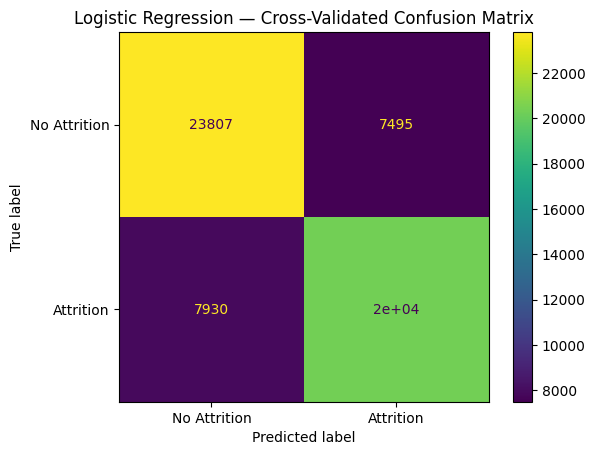


========== Linear SVC ==========
Confusion Matrix:
[[23812  7490]
 [ 7942 20354]]


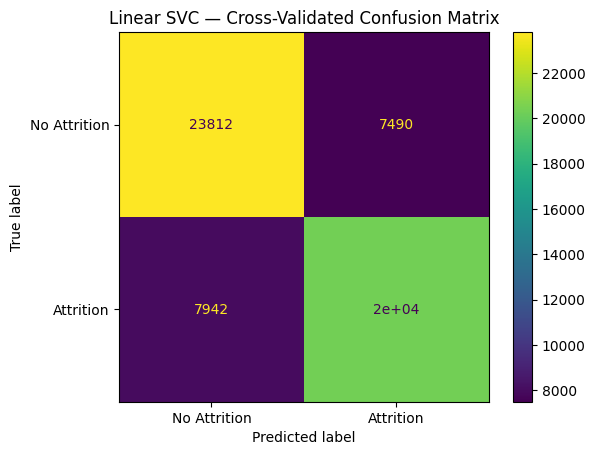


========== Naive Bayes ==========
Confusion Matrix:
[[23458  7844]
 [ 8137 20159]]


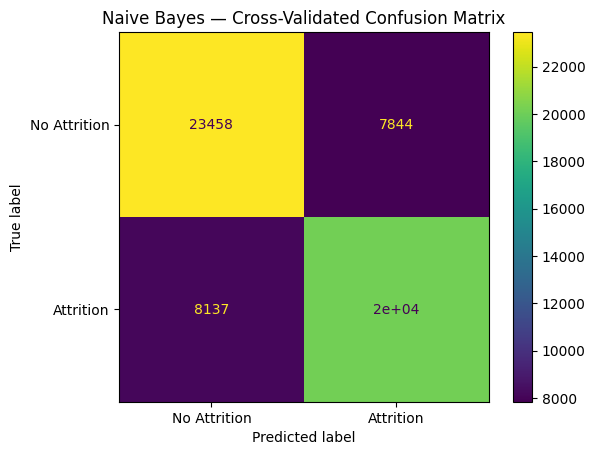


========== Random Forest ==========
Confusion Matrix:
[[24206  7096]
 [ 7900 20396]]


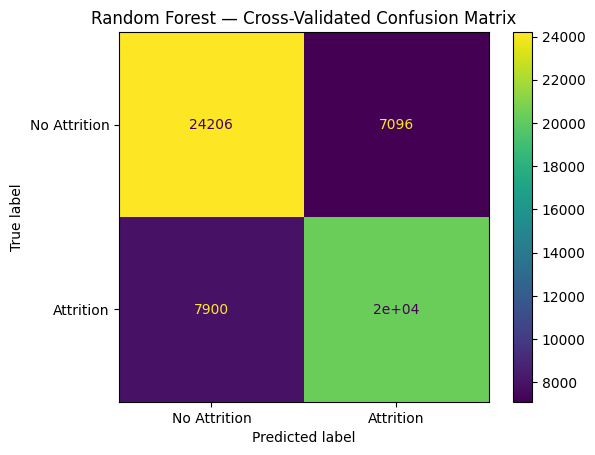


========== XGBoost ==========
Confusion Matrix:
[[24210  7092]
 [ 7181 21115]]


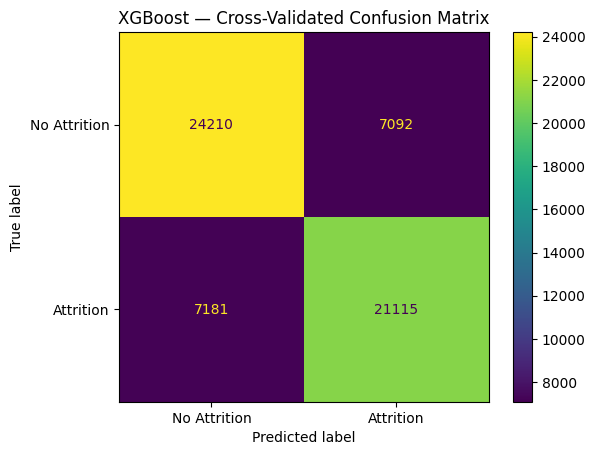

In [22]:
for name, model in models.items():
    print(f"\n========== {name} ==========")

    y_pred = cross_val_predict(
        model, X_train, y_train,
        cv=skf
    )

    cm = confusion_matrix(y_train, y_pred)
    print("Confusion Matrix:")
    print(cm)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Attrition", "Attrition"]
    )
    disp.plot()
    plt.title(f"{name} — Cross-Validated Confusion Matrix")
    plt.show()

# Threshold Tuning for Best Model (XGBoost)
Fit on X_train, evaluate on X_test

In [23]:
best_model = models["XGBoost"]
best_model.fit(X_train, y_train)   # pipeline fits preprocessor on X_train, transforms X_test

y_prob = best_model.predict_proba(X_test)[:, 1]

# Find best threshold by F1
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores      = (2 * precision_vals[:-1] * recall_vals[:-1]) / (precision_vals[:-1] + recall_vals[:-1] + 1e-9)
best_threshold = thresholds[f1_scores.argmax()]

print(f"Best Threshold: {best_threshold:.3f}")

print("\n── Default (0.5) ──")
print(classification_report(y_test, (y_prob >= 0.50).astype(int), target_names=['Stayed', 'Left']))

print(f"\n── Tuned ({best_threshold:.3f}) ──")
print(classification_report(y_test, (y_prob >= best_threshold).astype(int), target_names=['Stayed', 'Left']))

Best Threshold: 0.348

── Default (0.5) ──
              precision    recall  f1-score   support

      Stayed       0.77      0.76      0.76      7826
        Left       0.74      0.75      0.74      7074

    accuracy                           0.75     14900
   macro avg       0.75      0.75      0.75     14900
weighted avg       0.75      0.75      0.75     14900


── Tuned (0.348) ──
              precision    recall  f1-score   support

      Stayed       0.85      0.61      0.71      7826
        Left       0.67      0.88      0.76      7074

    accuracy                           0.74     14900
   macro avg       0.76      0.74      0.74     14900
weighted avg       0.76      0.74      0.73     14900



# SHAP Explainability

Rank  Feature                          → LEFT   → STAYED
  1    Job Level                        41.4%      58.6%
  2    Marital Status_Single            37.8%      62.2%
  3    Work-Life Balance                46.4%      53.6%
  4    Remote Work                      81.6%      18.4%
  5    Company Reputation               39.2%      60.8%
  6    Distance from Home               51.6%      48.4%
  7    Gender                           42.2%      57.8%
  8    Number of Dependents             82.6%      17.4%
  9    Years at Company                 35.4%      64.6%
  10   Number of Promotions             92.6%       7.4%


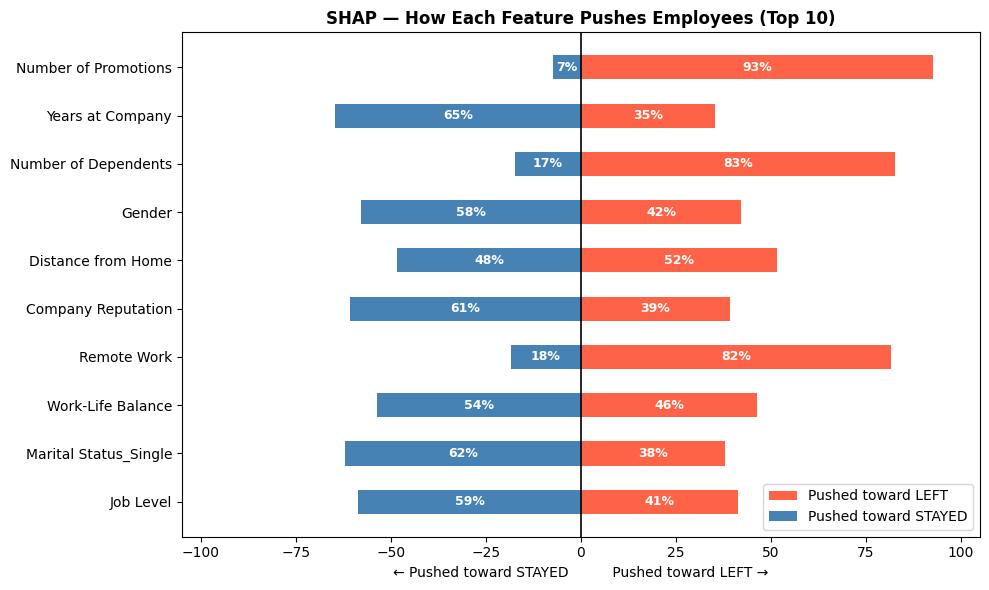

In [24]:
# Extract the fitted XGBoost model from inside the pipeline
xgb_model = best_model.named_steps['model']

# Transform X_test through the preprocessor to get the numeric array SHAP expects
X_test_transformed = best_model.named_steps['preprocessor'].transform(X_test)

# Build feature names after ColumnTransformer (for readable SHAP plots)
ohe_feature_names = (
    best_model.named_steps['preprocessor']
    .named_transformers_['ohe']
    .named_steps['encoder']
    .get_feature_names_out(ohe_cols)
    .tolist()
)
all_feature_names = numerical_cols + ordinal_cols + binary_cols + ohe_feature_names

X_sample = X_test_transformed[:500]

explainer = shap.TreeExplainer(xgb_model)
shap_vals = explainer.shap_values(X_sample)

shap_df = pd.DataFrame({
    'Feature'      : all_feature_names,
    'Mean SHAP'    : np.abs(shap_vals).mean(axis=0),
    'Positive SHAP': (shap_vals > 0).mean(axis=0) * 100,
    'Negative SHAP': (shap_vals < 0).mean(axis=0) * 100,
}).sort_values('Mean SHAP', ascending=False).head(10).reset_index(drop=True)

print("=" * 65)
print(f"{'Rank':<5} {'Feature':<30} {'→ LEFT':>8} {'→ STAYED':>10}")
print("=" * 65)
for i, row in shap_df.iterrows():
    print(f"  {i+1:<4} {row['Feature']:<30} {row['Positive SHAP']:>6.1f}%  {row['Negative SHAP']:>8.1f}%")
print("=" * 65)

fig, ax = plt.subplots(figsize=(10, 6))
features  = shap_df['Feature']
left_pct  = shap_df['Positive SHAP']
stay_pct  = shap_df['Negative SHAP']
y_pos     = np.arange(len(features))

ax.barh(y_pos,  left_pct, color='tomato',    label='Pushed toward LEFT',   height=0.5)
ax.barh(y_pos, -stay_pct, color='steelblue', label='Pushed toward STAYED', height=0.5)

for i, (l, s) in enumerate(zip(left_pct, stay_pct)):
    ax.text( l/2, i, f'{l:.0f}%', va='center', ha='center', color='white', fontsize=9, fontweight='bold')
    ax.text(-s/2, i, f'{s:.0f}%', va='center', ha='center', color='white', fontsize=9, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(features, fontsize=10)
ax.axvline(0, color='black', linewidth=1.2)
ax.set_xlabel('← Pushed toward STAYED          Pushed toward LEFT →')
ax.set_title('SHAP — How Each Feature Pushes Employees (Top 10)', fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim(-105, 105)
plt.tight_layout()
plt.show()

# HyperParameter Tuning

XGBoost RandomizedSearchCV

In [25]:
# param keys use 'model__' prefix because 'model' is the step name in pipeline
xgb_param_grid = {
    'model__n_estimators':     [400, 600, 800],
    'model__learning_rate':    [0.01, 0.03, 0.05, 0.1],
    'model__max_depth':        [3, 4, 5, 6],
    'model__subsample':        [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0],
    'model__gamma':            [0, 0.1, 0.3],
    'model__min_child_weight': [1, 3, 5],
    'model__reg_alpha':        [0, 0.1, 0.5],
    'model__reg_lambda':       [1, 1.5, 2.0],
}

xgb_search = RandomizedSearchCV(
    models["XGBoost"],      # full pipeline: preprocessor + XGBoost
    xgb_param_grid,
    n_iter=40,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1,
    refit=True
)

xgb_search.fit(X_train, y_train)   # ← raw X_train, pipeline preprocesses internally

print("Best XGBoost Params:", xgb_search.best_params_)
print(f"\nBest CV ROC-AUC (on train): {xgb_search.best_score_:.4f}")

# Evaluate on held-out test set
y_prob_tuned = xgb_search.best_estimator_.predict_proba(X_test)[:, 1]
print(f"\nTuned model Test ROC-AUC: {roc_auc_score(y_test, y_prob_tuned):.4f}")
print("\nTuned Model — Test Set Report:")
print(classification_report(
    y_test,
    (y_prob_tuned >= best_threshold).astype(int),
    target_names=['Stayed', 'Left']
))


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best XGBoost Params: {'model__subsample': 1.0, 'model__reg_lambda': 2.0, 'model__reg_alpha': 0.1, 'model__n_estimators': 600, 'model__min_child_weight': 1, 'model__max_depth': 3, 'model__learning_rate': 0.03, 'model__gamma': 0.3, 'model__colsample_bytree': 0.7}

Best CV ROC-AUC (on train): 0.8513

Tuned model Test ROC-AUC: 0.8499

Tuned Model — Test Set Report:
              precision    recall  f1-score   support

      Stayed       0.85      0.61      0.71      7826
        Left       0.67      0.88      0.76      7074

    accuracy                           0.74     14900
   macro avg       0.76      0.74      0.73     14900
weighted avg       0.76      0.74      0.73     14900



Pickle file

In [26]:
final_pipeline = xgb_search.best_estimator_

# Save single pipeline pickle — contains everything
with open('attrition_pipeline.pkl', 'wb') as f:
    pickle.dump(final_pipeline, f)

# Save best threshold separately (not part of sklearn pipeline)
with open('best_threshold.pkl', 'wb') as f:
    pickle.dump(float(best_threshold), f)

# Save feature names for reference/debugging
feature_names = list(X.columns)
with open('feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

print("attrition_pipeline.pkl  — full pipeline (preprocessor + tuned XGBoost)")
print(f"best_threshold.pkl  — threshold = {best_threshold:.3f}")
print(f"feature_names.pkl — {len(feature_names)} input features")


attrition_pipeline.pkl  — full pipeline (preprocessor + tuned XGBoost)
best_threshold.pkl  — threshold = 0.348
feature_names.pkl — 25 input features


In [27]:
from google.colab import files
files.download('attrition_pipeline.pkl')
files.download('best_threshold.pkl')
files.download('feature_names.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>